Loading required package: nnet



DIRECT PARAMETER PREDICTION MODEL
Model: y = w0 + w1*x + w2*x^2 + e
Noise: e ~ N(0, |yi|)
Task: m(Ri, Di) -> delta_theta_i
delta_theta_i = theta_full - theta_retained_i
Total raw points: 100 

Generated 200 experiments
Generated 400 experiments
Generated 600 experiments
Generated 800 experiments
Generated 1000 experiments
Generated 1200 experiments
Generated 1400 experiments
Generated 1600 experiments
Generated 1800 experiments
Generated 2000 experiments
Total experiments built: 2000 

Total meta rows built: 2000 

Summary of delta theta targets:
 target_delta_theta_1 target_delta_theta_2 target_delta_theta_3
 Min.   :-2.228e-01   Min.   :-1.808e-01   Min.   :-0.2074445  
 1st Qu.:-3.118e-02   1st Qu.:-2.419e-02   1st Qu.:-0.0264555  
 Median :-1.489e-04   Median :-6.858e-05   Median : 0.0001790  
 Mean   : 6.990e-06   Mean   :-1.835e-04   Mean   :-0.0008179  
 3rd Qu.: 3.303e-02   3rd Qu.: 2.253e-02   3rd Qu.: 0.0274356  
 Max.   : 2.524e-01   Max.   : 1.758e-01   Max.   : 0.2011316  

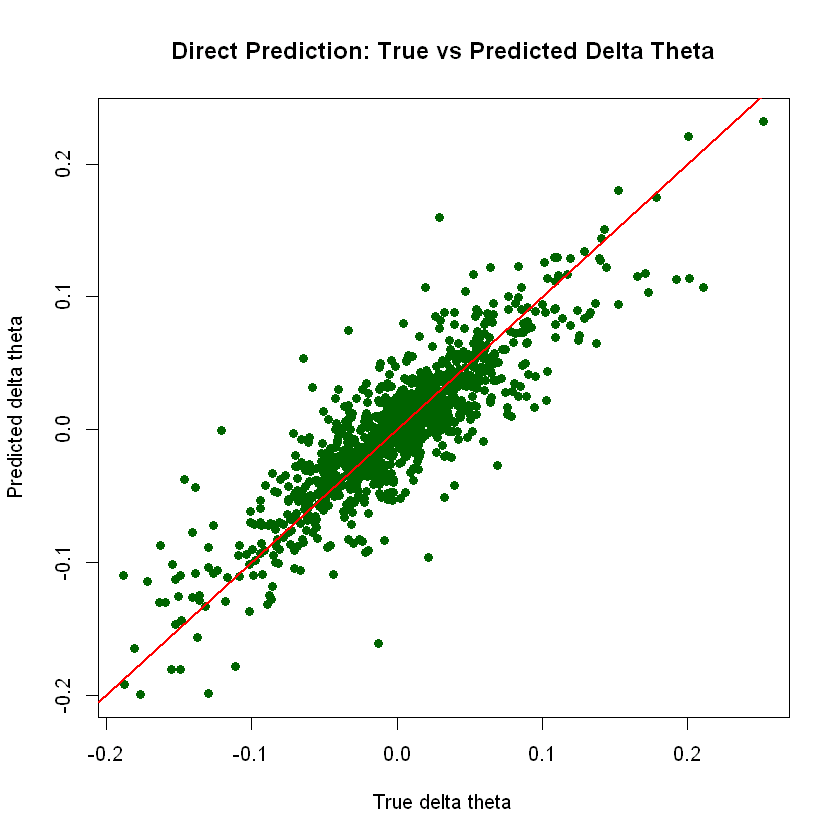

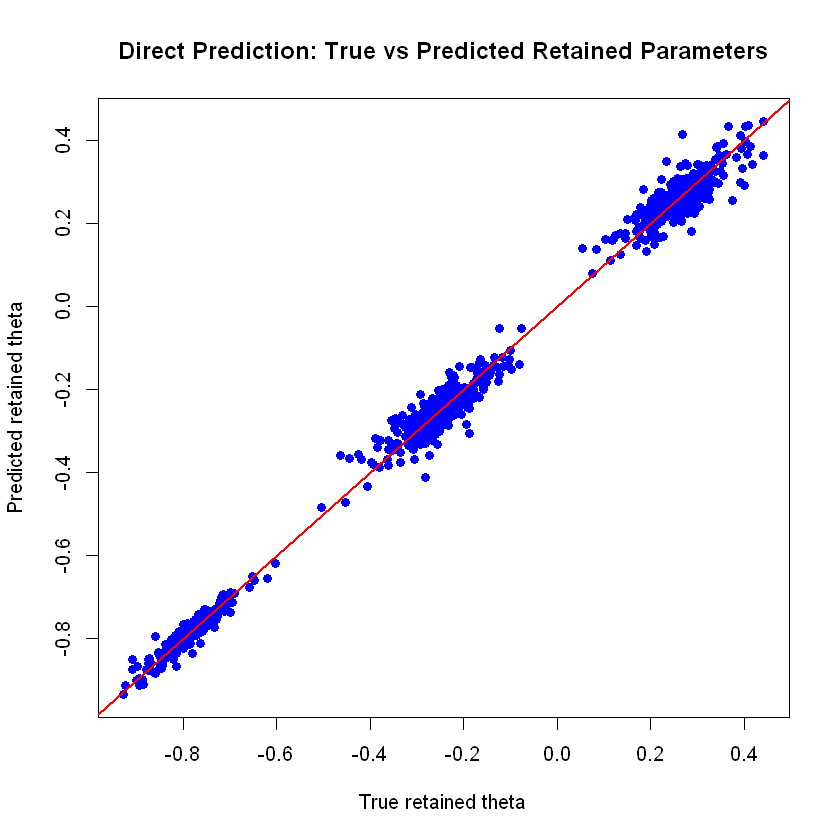

In [1]:
# ============================================================
# DIRECT PARAMETER PREDICTION
# Nonlinear polynomial Gaussian model
#
# y = w0 + w1*x + w2*x^2 + e
# e ~ N(0, |yi|)
#
# Task:
# m(Ri, Di) -> delta_theta_i
#
# delta_theta_i = theta_full - theta_retained_i
# theta_pred_retained = theta_full - predicted_delta_theta
# ============================================================

set.seed(42)

if (!require(nnet)) install.packages("nnet", repos = "https://cloud.r-project.org")
library(nnet)

safe_sd <- function(x) {
  if (length(x) <= 1) return(0)
  s <- sd(x)
  if (is.na(s) || is.nan(s) || is.infinite(s)) return(0)
  s
}

make_poly_design <- function(x, degree_terms = 3) {
  Phi <- sapply(0:(degree_terms - 1), function(k) x^k)
  colnames(Phi) <- paste0("x_power_", 0:(degree_terms - 1))
  as.matrix(Phi)
}

simulate_polynomial_gaussian_yi <- function(
    n = 100,
    degree_terms = 3,
    theta_true = c(2, -3, 1.5),
    x_min = -1,
    x_max = 1,
    min_sd = 0.001,
    seed = NULL
) {
  if (!is.null(seed)) set.seed(seed)

  x <- runif(n, x_min, x_max)
  Phi <- make_poly_design(x, degree_terms)

  y_true <- as.vector(Phi %*% theta_true)

  sigma_i <- sqrt(pmax(abs(y_true), min_sd))
  eps <- rnorm(n, mean = 0, sd = sigma_i)

  y_obs <- y_true + eps

  data.frame(
    x = x,
    y = y_obs,
    y_true = y_true,
    sigma_i = sigma_i
  )
}

standardize_xy <- function(x, y) {
  x_sd <- safe_sd(x)
  y_sd <- safe_sd(y)

  if (x_sd == 0) x_sd <- 1
  if (y_sd == 0) y_sd <- 1

  list(
    x = (x - mean(x)) / x_sd,
    y = (y - mean(y)) / y_sd
  )
}

mse_loss <- function(theta, Phi, Y) {
  pred <- as.vector(Phi %*% theta)
  mean((Y - pred)^2)
}

fit_optim_bfgs <- function(Phi, Y, theta_init = NULL, maxit = 1000) {
  if (is.null(theta_init)) {
    theta_init <- rep(0, ncol(Phi))
  }

  fit <- optim(
    par = theta_init,
    fn = mse_loss,
    Phi = Phi,
    Y = Y,
    method = "BFGS",
    control = list(maxit = maxit)
  )

  fit$par
}

one_experiment_delta_theta <- function(
    df,
    p_del,
    degree_terms = 3,
    T_GD = 1000
) {
  x <- df$x
  y <- df$y
  n <- nrow(df)

  K_del <- max(1, floor(n * p_del))
  K_del <- min(K_del, n - 1)

  st <- standardize_xy(x, y)
  X <- st$x
  Y <- st$y

  Phi <- make_poly_design(X, degree_terms)

  theta_full <- fit_optim_bfgs(
    Phi = Phi,
    Y = Y,
    maxit = T_GD
  )

  del_idx <- sample(1:n, K_del, replace = FALSE)

  del_mask <- rep(FALSE, n)
  del_mask[del_idx] <- TRUE

  Phi_ret <- Phi[!del_mask, , drop = FALSE]
  Y_ret <- Y[!del_mask]

  theta_ret <- fit_optim_bfgs(
    Phi = Phi_ret,
    Y = Y_ret,
    maxit = T_GD
  )

  delta_theta <- theta_full - theta_ret

  deleted_points <- as.matrix(df[del_mask, c("x", "y")])
  retained_points <- as.matrix(df[!del_mask, c("x", "y")])

  deleted_points <- deleted_points[order(deleted_points[, 1]), , drop = FALSE]
  retained_points <- retained_points[order(retained_points[, 1]), , drop = FALSE]

  list(
    deleted_points = deleted_points,
    retained_points = retained_points,
    theta_full = theta_full,
    theta_ret = theta_ret,
    delta_theta = delta_theta,
    K_del = K_del,
    p_del = p_del
  )
}

build_experiment_dataset <- function(
    df,
    n_experiments = 2000,
    degree_terms = 3,
    p_min = 0.01,
    p_max = 0.50,
    T_GD = 1000
) {
  samples <- vector("list", n_experiments)

  for (i in 1:n_experiments) {
    p_now <- runif(1, p_min, p_max)

    samples[[i]] <- one_experiment_delta_theta(
      df = df,
      p_del = p_now,
      degree_terms = degree_terms,
      T_GD = T_GD
    )

    if (i %% 200 == 0) {
      cat("Generated", i, "experiments\n")
    }
  }

  samples
}

embed_and_pool <- function(points_mat, W, b) {
  if (nrow(points_mat) == 0) stop("Empty point set")

  embedded <- sweep(points_mat %*% W, 2, b, "+")

  c(
    colMeans(embedded),
    apply(embedded, 2, max),
    apply(embedded, 2, min),
    apply(embedded, 2, safe_sd)
  )
}

build_meta_table <- function(
    samples,
    embed_dim = 16,
    total_raw_n = 100,
    theta_dim = 3,
    seed = 42
) {
  set.seed(seed)

  W <- matrix(
    rnorm(2 * embed_dim, mean = 0, sd = 0.3),
    nrow = 2,
    ncol = embed_dim
  )

  b <- rnorm(embed_dim, mean = 0, sd = 0.05)

  rows <- vector("list", length(samples))

  for (i in seq_along(samples)) {
    s <- samples[[i]]

    del_vec <- embed_and_pool(s$deleted_points, W, b)
    ret_vec <- embed_and_pool(s$retained_points, W, b)

    row_i <- as.data.frame(as.list(c(del_vec, ret_vec)))

    names(row_i) <- c(
      paste0("del_mean_emb_", 1:embed_dim),
      paste0("del_max_emb_", 1:embed_dim),
      paste0("del_min_emb_", 1:embed_dim),
      paste0("del_sd_emb_", 1:embed_dim),
      paste0("ret_mean_emb_", 1:embed_dim),
      paste0("ret_max_emb_", 1:embed_dim),
      paste0("ret_min_emb_", 1:embed_dim),
      paste0("ret_sd_emb_", 1:embed_dim)
    )

    row_i$p_del <- s$p_del
    row_i$K_del <- s$K_del
    row_i$del_fraction <- s$K_del / total_raw_n

    for (j in 1:theta_dim) {
      row_i[[paste0("theta_full_", j)]] <- s$theta_full[j]
      row_i[[paste0("target_delta_theta_", j)]] <- s$delta_theta[j]
      row_i[[paste0("target_theta_ret_", j)]] <- s$theta_ret[j]
    }

    rows[[i]] <- row_i
  }

  na.omit(do.call(rbind, rows))
}

scale_features_train <- function(df_features) {
  means <- sapply(df_features, mean)
  sds <- sapply(df_features, safe_sd)
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  list(data = scaled, means = means, sds = sds)
}

scale_features_apply <- function(df_features, means, sds) {
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  scaled
}

scale_targets_train <- function(Y) {
  means <- apply(Y, 2, mean)
  sds <- apply(Y, 2, safe_sd)
  sds[sds == 0] <- 1

  Y_scaled <- scale(Y, center = means, scale = sds)

  list(
    data = as.matrix(Y_scaled),
    means = means,
    sds = sds
  )
}

scale_targets_apply_inverse <- function(Y_scaled, means, sds) {
  sweep(
    sweep(Y_scaled, 2, sds, "*"),
    2,
    means,
    "+"
  )
}

fit_best_nnet_multi <- function(
    x_train_sc,
    y_train_sc,
    hidden_units = 8,
    decay = 0.001,
    maxit = 1500,
    maxnwts = 30000,
    n_repeats = 5,
    seed = 42
) {
  best_fit <- NULL
  best_sse <- Inf

  for (r in 1:n_repeats) {
    set.seed(seed + r)

    fit_try <- try(
      nnet(
        x = x_train_sc,
        y = y_train_sc,
        size = hidden_units,
        linout = TRUE,
        decay = decay,
        maxit = maxit,
        trace = FALSE,
        MaxNWts = maxnwts
      ),
      silent = TRUE
    )

    if (inherits(fit_try, "try-error")) next

    pred_train <- as.matrix(predict(fit_try, x_train_sc))
    sse <- sum((pred_train - y_train_sc)^2)

    if (is.finite(sse) && sse < best_sse) {
      best_sse <- sse
      best_fit <- fit_try
    }
  }

  if (is.null(best_fit)) {
    stop("All MLP fits failed.")
  }

  best_fit
}

train_and_test_delta_theta_model <- function(
    meta_train,
    meta_test,
    theta_dim = 3,
    hidden_units = 8,
    seed = 42
) {
  delta_cols <- paste0("target_delta_theta_", 1:theta_dim)
  theta_ret_cols <- paste0("target_theta_ret_", 1:theta_dim)
  theta_full_cols <- paste0("theta_full_", 1:theta_dim)

  target_cols <- c(delta_cols, theta_ret_cols)

  feature_names <- setdiff(names(meta_train), target_cols)

  x_train <- meta_train[, feature_names, drop = FALSE]
  x_test <- meta_test[, feature_names, drop = FALSE]

  y_train_delta <- as.matrix(meta_train[, delta_cols, drop = FALSE])
  y_test_delta <- as.matrix(meta_test[, delta_cols, drop = FALSE])

  y_test_theta_ret <- as.matrix(meta_test[, theta_ret_cols, drop = FALSE])
  theta_full_test <- as.matrix(meta_test[, theta_full_cols, drop = FALSE])

  sc_x <- scale_features_train(x_train)
  x_train_sc <- as.matrix(sc_x$data)
  x_test_sc <- as.matrix(scale_features_apply(x_test, sc_x$means, sc_x$sds))

  sc_y <- scale_targets_train(y_train_delta)
  y_train_sc <- sc_y$data

  mlp_fit <- fit_best_nnet_multi(
    x_train_sc = x_train_sc,
    y_train_sc = y_train_sc,
    hidden_units = hidden_units,
    seed = seed
  )

  pred_delta_sc <- as.matrix(predict(mlp_fit, x_test_sc))

  pred_delta <- scale_targets_apply_inverse(
    pred_delta_sc,
    sc_y$means,
    sc_y$sds
  )

  pred_theta_ret <- theta_full_test - pred_delta

  delta_rmse <- sqrt(mean((pred_delta - y_test_delta)^2))
  delta_mae <- mean(abs(pred_delta - y_test_delta))

  theta_rmse <- sqrt(mean((pred_theta_ret - y_test_theta_ret)^2))
  theta_mae <- mean(abs(pred_theta_ret - y_test_theta_ret))

  per_param_rmse_delta <- sqrt(colMeans((pred_delta - y_test_delta)^2))
  per_param_rmse_theta <- sqrt(colMeans((pred_theta_ret - y_test_theta_ret)^2))

  list(
    pred_delta = pred_delta,
    true_delta = y_test_delta,
    pred_theta_ret = pred_theta_ret,
    true_theta_ret = y_test_theta_ret,
    delta_rmse = delta_rmse,
    delta_mae = delta_mae,
    theta_rmse = theta_rmse,
    theta_mae = theta_mae,
    per_param_rmse_delta = per_param_rmse_delta,
    per_param_rmse_theta = per_param_rmse_theta
  )
}

# ============================================================
# MAIN
# ============================================================

degree_terms <- 3
theta_dim <- degree_terms

base_df <- simulate_polynomial_gaussian_yi(
  n = 100,
  degree_terms = degree_terms,
  theta_true = c(2, -3, 1.5),
  x_min = -1,
  x_max = 1,
  seed = 7
)

cat("DIRECT PARAMETER PREDICTION MODEL\n")
cat("Model: y = w0 + w1*x + w2*x^2 + e\n")
cat("Noise: e ~ N(0, |yi|)\n")
cat("Task: m(Ri, Di) -> delta_theta_i\n")
cat("delta_theta_i = theta_full - theta_retained_i\n")
cat("Total raw points:", nrow(base_df), "\n\n")

samples <- build_experiment_dataset(
  df = base_df,
  n_experiments = 2000,
  degree_terms = degree_terms,
  p_min = 0.01,
  p_max = 0.50,
  T_GD = 1000
)

cat("Total experiments built:", length(samples), "\n\n")

meta_all <- build_meta_table(
  samples = samples,
  embed_dim = 16,
  total_raw_n = nrow(base_df),
  theta_dim = theta_dim,
  seed = 42
)

cat("Total meta rows built:", nrow(meta_all), "\n\n")

delta_cols <- paste0("target_delta_theta_", 1:theta_dim)

cat("Summary of delta theta targets:\n")
print(summary(meta_all[, delta_cols]))

set.seed(42)

idx_meta_train <- sample(
  seq_len(nrow(meta_all)),
  size = floor(0.8 * nrow(meta_all))
)

meta_train <- meta_all[idx_meta_train, ]
meta_test <- meta_all[-idx_meta_train, ]

cat("\nMeta-train rows:", nrow(meta_train), "\n")
cat("Meta-test rows :", nrow(meta_test), "\n\n")

res <- train_and_test_delta_theta_model(
  meta_train = meta_train,
  meta_test = meta_test,
  theta_dim = theta_dim,
  hidden_units = 8,
  seed = 42
)

cat("Delta theta RMSE:", res$delta_rmse, "\n")
cat("Delta theta MAE :", res$delta_mae, "\n")
cat("Theta retained RMSE:", res$theta_rmse, "\n")
cat("Theta retained MAE :", res$theta_mae, "\n\n")

cat("Per-parameter delta RMSE:\n")
print(res$per_param_rmse_delta)

cat("\nPer-parameter retained theta RMSE:\n")
print(res$per_param_rmse_theta)

plot(
  as.vector(res$true_delta),
  as.vector(res$pred_delta),
  pch = 16,
  col = "darkgreen",
  xlab = "True delta theta",
  ylab = "Predicted delta theta",
  main = "Direct Prediction: True vs Predicted Delta Theta"
)

abline(0, 1, col = "red", lwd = 2)

plot(
  as.vector(res$true_theta_ret),
  as.vector(res$pred_theta_ret),
  pch = 16,
  col = "blue",
  xlab = "True retained theta",
  ylab = "Predicted retained theta",
  main = "Direct Prediction: True vs Predicted Retained Parameters"
)

abline(0, 1, col = "red", lwd = 2)

DIRECT SCALAR PARAMETER-DISTANCE PREDICTION
Model: y = w0 + w1*x + w2*x^2 + e
Noise: e ~ N(0, |yi|)
Task: m(Ri, Di) -> ||theta_full - theta_retained||^2
Total raw points: 100 

Generated 200 experiments
Generated 400 experiments
Generated 600 experiments
Generated 800 experiments
Generated 1000 experiments
Generated 1200 experiments
Generated 1400 experiments
Generated 1600 experiments
Generated 1800 experiments
Generated 2000 experiments
Total experiments built: 2000 

Total meta rows built: 2000 

Summary of scalar target ||delta theta||^2:
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
7.000e-08 1.068e-03 3.506e-03 8.244e-03 9.804e-03 1.141e-01 

Meta-train rows: 1600 
Meta-test rows : 400 

Scalar target RMSE: 0.01017132 
Scalar target MAE : 0.006449685 
Mean signed error : 0.000722162 
Under-prediction rate: 0.46 
Over-prediction rate : 0.54 


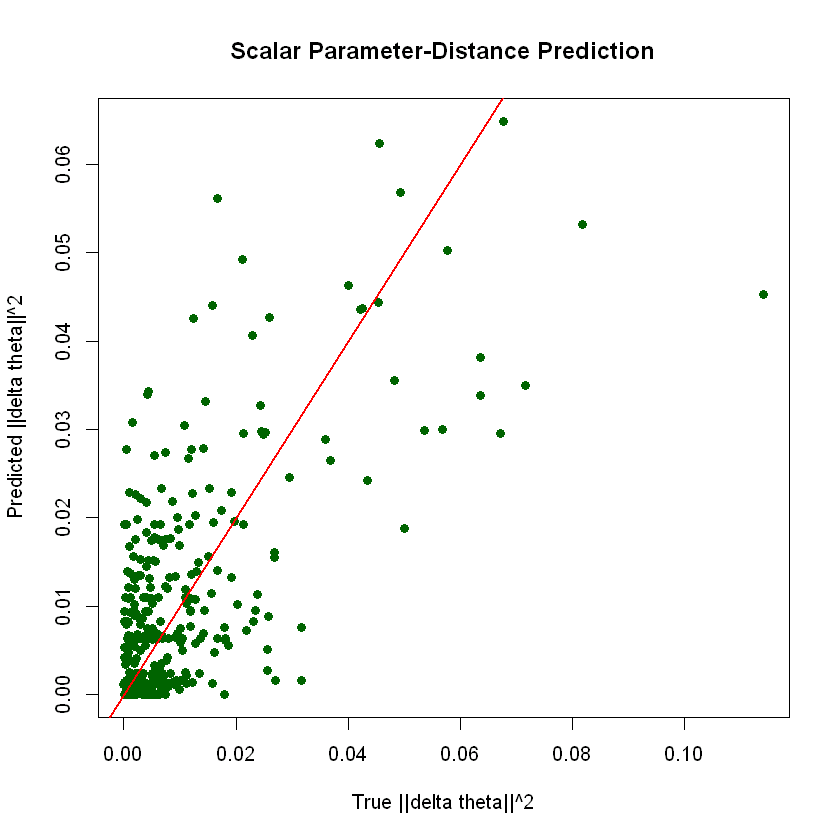

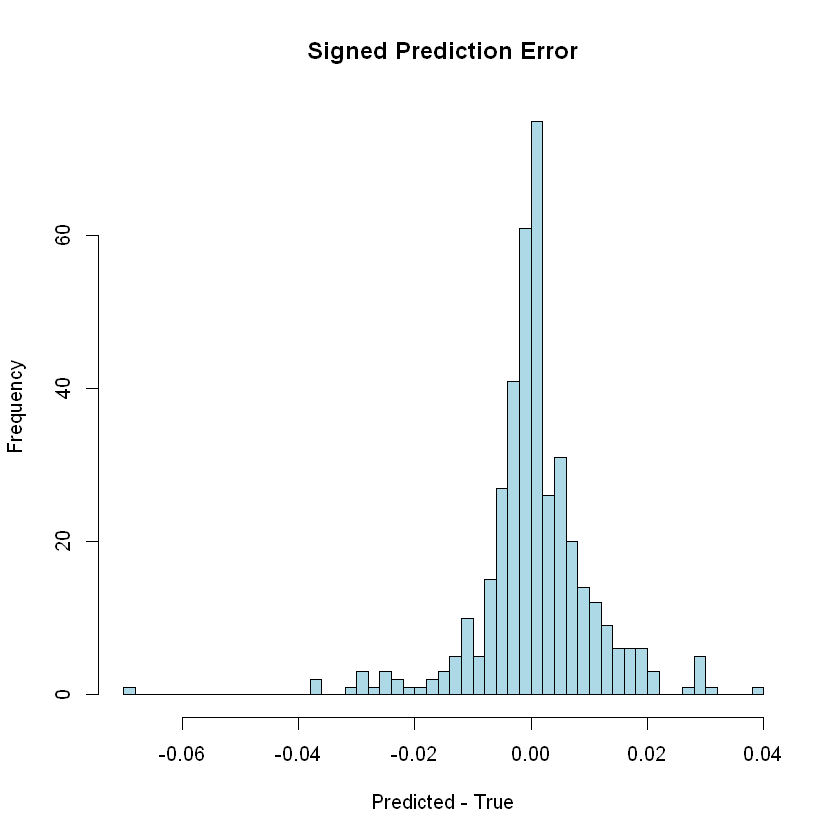

In [3]:
# ============================================================
# DIRECT SCALAR PARAMETER-DISTANCE PREDICTION
#
# Model:
# y = w0 + w1*x + w2*x^2 + e
# e ~ N(0, |yi|)
#
# Task:
# m(Ri, Di) -> ||theta_full - theta_retained||^2
# ============================================================

set.seed(42)

if (!require(nnet)) install.packages("nnet", repos = "https://cloud.r-project.org")
library(nnet)

safe_sd <- function(x) {
  if (length(x) <= 1) return(0)
  s <- sd(x)
  if (is.na(s) || is.nan(s) || is.infinite(s)) return(0)
  s
}

make_poly_design <- function(x, degree_terms = 3) {
  Phi <- sapply(0:(degree_terms - 1), function(k) x^k)
  colnames(Phi) <- paste0("x_power_", 0:(degree_terms - 1))
  as.matrix(Phi)
}

simulate_polynomial_gaussian_yi <- function(
    n = 100,
    degree_terms = 3,
    theta_true = c(2, -3, 1.5),
    x_min = -1,
    x_max = 1,
    min_sd = 0.001,
    seed = NULL
) {
  if (!is.null(seed)) set.seed(seed)

  x <- runif(n, x_min, x_max)
  Phi <- make_poly_design(x, degree_terms)

  y_true <- as.vector(Phi %*% theta_true)
  sigma_i <- sqrt(pmax(abs(y_true), min_sd))

  eps <- rnorm(n, mean = 0, sd = sigma_i)
  y_obs <- y_true + eps

  data.frame(
    x = x,
    y = y_obs,
    y_true = y_true,
    sigma_i = sigma_i
  )
}

standardize_xy <- function(x, y) {
  x_sd <- safe_sd(x)
  y_sd <- safe_sd(y)

  if (x_sd == 0) x_sd <- 1
  if (y_sd == 0) y_sd <- 1

  list(
    x = (x - mean(x)) / x_sd,
    y = (y - mean(y)) / y_sd
  )
}

mse_loss <- function(theta, Phi, Y) {
  pred <- as.vector(Phi %*% theta)
  mean((Y - pred)^2)
}

fit_optim_bfgs <- function(Phi, Y, theta_init = NULL, maxit = 1000) {
  if (is.null(theta_init)) {
    theta_init <- rep(0, ncol(Phi))
  }

  fit <- optim(
    par = theta_init,
    fn = mse_loss,
    Phi = Phi,
    Y = Y,
    method = "BFGS",
    control = list(maxit = maxit)
  )

  fit$par
}

one_experiment_scalar_delta <- function(
    df,
    p_del,
    degree_terms = 3,
    T_GD = 1000
) {
  x <- df$x
  y <- df$y
  n <- nrow(df)

  K_del <- max(1, floor(n * p_del))
  K_del <- min(K_del, n - 1)

  st <- standardize_xy(x, y)
  X <- st$x
  Y <- st$y

  Phi <- make_poly_design(X, degree_terms)

  theta_full <- fit_optim_bfgs(
    Phi = Phi,
    Y = Y,
    maxit = T_GD
  )

  del_idx <- sample(1:n, K_del, replace = FALSE)

  del_mask <- rep(FALSE, n)
  del_mask[del_idx] <- TRUE

  Phi_ret <- Phi[!del_mask, , drop = FALSE]
  Y_ret <- Y[!del_mask]

  theta_ret <- fit_optim_bfgs(
    Phi = Phi_ret,
    Y = Y_ret,
    maxit = T_GD
  )

  delta_theta <- theta_full - theta_ret

  delta_theta_sqdist <- sum(delta_theta^2)

  deleted_points <- as.matrix(df[del_mask, c("x", "y")])
  retained_points <- as.matrix(df[!del_mask, c("x", "y")])

  deleted_points <- deleted_points[order(deleted_points[, 1]), , drop = FALSE]
  retained_points <- retained_points[order(retained_points[, 1]), , drop = FALSE]

  list(
    deleted_points = deleted_points,
    retained_points = retained_points,
    theta_full = theta_full,
    theta_ret = theta_ret,
    delta_theta = delta_theta,
    delta_theta_sqdist = delta_theta_sqdist,
    K_del = K_del,
    p_del = p_del
  )
}

build_experiment_dataset <- function(
    df,
    n_experiments = 2000,
    degree_terms = 3,
    p_min = 0.01,
    p_max = 0.50,
    T_GD = 1000
) {
  samples <- vector("list", n_experiments)

  for (i in 1:n_experiments) {
    p_now <- runif(1, p_min, p_max)

    samples[[i]] <- one_experiment_scalar_delta(
      df = df,
      p_del = p_now,
      degree_terms = degree_terms,
      T_GD = T_GD
    )

    if (i %% 200 == 0) {
      cat("Generated", i, "experiments\n")
    }
  }

  samples
}

embed_and_pool <- function(points_mat, W, b) {
  if (nrow(points_mat) == 0) stop("Empty point set")

  embedded <- sweep(points_mat %*% W, 2, b, "+")

  c(
    colMeans(embedded),
    apply(embedded, 2, max),
    apply(embedded, 2, min),
    apply(embedded, 2, safe_sd)
  )
}

build_meta_table <- function(
    samples,
    embed_dim = 16,
    total_raw_n = 100,
    seed = 42
) {
  set.seed(seed)

  W <- matrix(
    rnorm(2 * embed_dim, mean = 0, sd = 0.3),
    nrow = 2,
    ncol = embed_dim
  )

  b <- rnorm(embed_dim, mean = 0, sd = 0.05)

  rows <- vector("list", length(samples))

  for (i in seq_along(samples)) {
    s <- samples[[i]]

    del_vec <- embed_and_pool(s$deleted_points, W, b)
    ret_vec <- embed_and_pool(s$retained_points, W, b)

    row_i <- as.data.frame(as.list(c(del_vec, ret_vec)))

    names(row_i) <- c(
      paste0("del_mean_emb_", 1:embed_dim),
      paste0("del_max_emb_", 1:embed_dim),
      paste0("del_min_emb_", 1:embed_dim),
      paste0("del_sd_emb_", 1:embed_dim),
      paste0("ret_mean_emb_", 1:embed_dim),
      paste0("ret_max_emb_", 1:embed_dim),
      paste0("ret_min_emb_", 1:embed_dim),
      paste0("ret_sd_emb_", 1:embed_dim)
    )

    row_i$p_del <- s$p_del
    row_i$K_del <- s$K_del
    row_i$del_fraction <- s$K_del / total_raw_n

    row_i$target_delta_theta_sqdist <- s$delta_theta_sqdist

    rows[[i]] <- row_i
  }

  na.omit(do.call(rbind, rows))
}

scale_features_train <- function(df_features) {
  means <- sapply(df_features, mean)
  sds <- sapply(df_features, safe_sd)
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  list(data = scaled, means = means, sds = sds)
}

scale_features_apply <- function(df_features, means, sds) {
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  scaled
}

fit_best_nnet <- function(
    x_train_sc,
    y_train,
    hidden_units = 8,
    decay = 0.001,
    maxit = 1500,
    maxnwts = 30000,
    n_repeats = 5,
    seed = 42
) {
  best_fit <- NULL
  best_sse <- Inf

  for (r in 1:n_repeats) {
    set.seed(seed + r)

    fit_try <- try(
      nnet(
        x = x_train_sc,
        y = y_train,
        size = hidden_units,
        linout = TRUE,
        decay = decay,
        maxit = maxit,
        trace = FALSE,
        MaxNWts = maxnwts
      ),
      silent = TRUE
    )

    if (inherits(fit_try, "try-error")) next

    pred_train <- as.numeric(predict(fit_try, x_train_sc))
    sse <- sum((pred_train - y_train)^2)

    if (is.finite(sse) && sse < best_sse) {
      best_sse <- sse
      best_fit <- fit_try
    }
  }

  if (is.null(best_fit)) stop("All MLP fits failed.")

  best_fit
}

train_and_test_scalar_model <- function(
    meta_train,
    meta_test,
    hidden_units = 8,
    seed = 42
) {
  target_col <- "target_delta_theta_sqdist"

  feature_names <- setdiff(names(meta_train), target_col)

  x_train <- meta_train[, feature_names, drop = FALSE]
  x_test <- meta_test[, feature_names, drop = FALSE]

  y_train_raw <- meta_train[[target_col]]
  y_test <- meta_test[[target_col]]

  y_mean <- mean(y_train_raw)
  y_sd <- safe_sd(y_train_raw)

  if (y_sd == 0) y_sd <- 1

  y_train_scaled <- (y_train_raw - y_mean) / y_sd

  sc_x <- scale_features_train(x_train)

  x_train_sc <- as.matrix(sc_x$data)
  x_test_sc <- as.matrix(
    scale_features_apply(x_test, sc_x$means, sc_x$sds)
  )

  mlp_fit <- fit_best_nnet(
    x_train_sc = x_train_sc,
    y_train = y_train_scaled,
    hidden_units = hidden_units,
    seed = seed
  )

  pred_scaled <- as.numeric(predict(mlp_fit, x_test_sc))

  pred_raw <- pred_scaled * y_sd + y_mean

  pred_raw <- pmax(0, pred_raw)

  rmse <- sqrt(mean((pred_raw - y_test)^2))
  mae <- mean(abs(pred_raw - y_test))

  signed_error <- pred_raw - y_test

  list(
    y_test = y_test,
    pred_raw = pred_raw,
    rmse = rmse,
    mae = mae,
    mean_signed_error = mean(signed_error),
    under_rate = mean(signed_error < 0),
    over_rate = mean(signed_error > 0)
  )
}

# ============================================================
# MAIN
# ============================================================

degree_terms <- 3

base_df <- simulate_polynomial_gaussian_yi(
  n = 100,
  degree_terms = degree_terms,
  theta_true = c(2, -3, 1.5),
  x_min = -1,
  x_max = 1,
  seed = 7
)

cat("DIRECT SCALAR PARAMETER-DISTANCE PREDICTION\n")
cat("Model: y = w0 + w1*x + w2*x^2 + e\n")
cat("Noise: e ~ N(0, |yi|)\n")
cat("Task: m(Ri, Di) -> ||theta_full - theta_retained||^2\n")
cat("Total raw points:", nrow(base_df), "\n\n")

samples <- build_experiment_dataset(
  df = base_df,
  n_experiments = 2000,
  degree_terms = degree_terms,
  p_min = 0.01,
  p_max = 0.50,
  T_GD = 1000
)

cat("Total experiments built:", length(samples), "\n\n")

meta_all <- build_meta_table(
  samples = samples,
  embed_dim = 16,
  total_raw_n = nrow(base_df),
  seed = 42
)

cat("Total meta rows built:", nrow(meta_all), "\n\n")

cat("Summary of scalar target ||delta theta||^2:\n")
print(summary(meta_all$target_delta_theta_sqdist))

set.seed(42)

idx_meta_train <- sample(
  seq_len(nrow(meta_all)),
  size = floor(0.8 * nrow(meta_all))
)

meta_train <- meta_all[idx_meta_train, ]
meta_test <- meta_all[-idx_meta_train, ]

cat("\nMeta-train rows:", nrow(meta_train), "\n")
cat("Meta-test rows :", nrow(meta_test), "\n\n")

res <- train_and_test_scalar_model(
  meta_train = meta_train,
  meta_test = meta_test,
  hidden_units = 8,
  seed = 42
)

cat("Scalar target RMSE:", res$rmse, "\n")
cat("Scalar target MAE :", res$mae, "\n")
cat("Mean signed error :", res$mean_signed_error, "\n")
cat("Under-prediction rate:", res$under_rate, "\n")
cat("Over-prediction rate :", res$over_rate, "\n")

plot(
  res$y_test,
  res$pred_raw,
  pch = 16,
  col = "darkgreen",
  xlab = "True ||delta theta||^2",
  ylab = "Predicted ||delta theta||^2",
  main = "Scalar Parameter-Distance Prediction"
)

abline(0, 1, col = "red", lwd = 2)

hist(
  res$pred_raw - res$y_test,
  breaks = 40,
  col = "lightblue",
  main = "Signed Prediction Error",
  xlab = "Predicted - True"
)
                

EXPERIMENT 3: DIRECT RETAINED PARAMETER PREDICTION
Model: y = w0 + w1*x + w2*x^2 + e
Noise: e ~ N(0, |yi|)
Task: m(Ri, Di) -> theta_retained
Total raw points: 100 

Generated 200 experiments
Generated 400 experiments
Generated 600 experiments
Generated 800 experiments
Generated 1000 experiments
Generated 1200 experiments
Generated 1400 experiments
Generated 1600 experiments
Generated 1800 experiments
Generated 2000 experiments
Total experiments built: 2000 

Total meta rows built: 2000 

Summary of retained theta targets:
 target_theta_ret_1 target_theta_ret_2 target_theta_ret_3
 Min.   :-0.50463   Min.   :-0.9592    Min.   :0.05364   
 1st Qu.:-0.28526   1st Qu.:-0.8059    1st Qu.:0.22734   
 Median :-0.25208   Median :-0.7833    Median :0.25460   
 Mean   :-0.25223   Mean   :-0.7832    Mean   :0.25559   
 3rd Qu.:-0.22105   3rd Qu.:-0.7592    3rd Qu.:0.28123   
 Max.   :-0.02946   Max.   :-0.6026    Max.   :0.46222   

Meta-train rows: 1600 
Meta-test rows : 400 

Theta retained RMSE

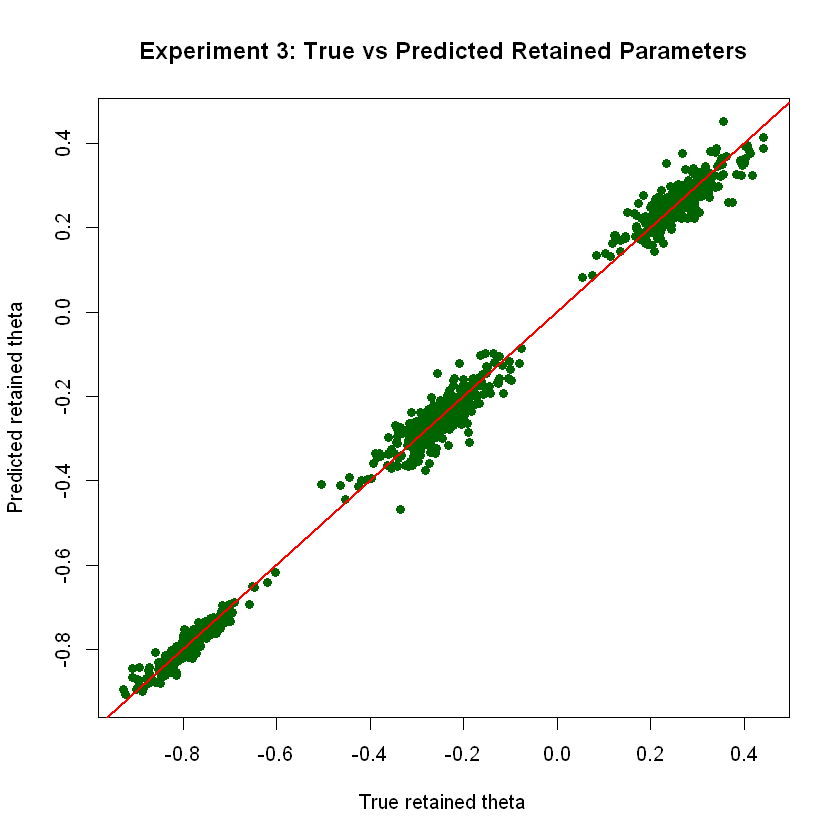

In [3]:
# ============================================================
# EXPERIMENT 3: DIRECT RETAINED PARAMETER PREDICTION
#
# Model:
# y = w0 + w1*x + w2*x^2 + e
# e ~ N(0, |yi|)
#
# Task:
# m(Ri, Di) -> theta_retained
# ============================================================

set.seed(42)

if (!require(nnet)) install.packages("nnet", repos = "https://cloud.r-project.org")
library(nnet)

safe_sd <- function(x) {
  if (length(x) <= 1) return(0)
  s <- sd(x)
  if (is.na(s) || is.nan(s) || is.infinite(s)) return(0)
  s
}

make_poly_design <- function(x, degree_terms = 3) {
  Phi <- sapply(0:(degree_terms - 1), function(k) x^k)
  colnames(Phi) <- paste0("x_power_", 0:(degree_terms - 1))
  as.matrix(Phi)
}

simulate_polynomial_gaussian_yi <- function(
    n = 100,
    degree_terms = 3,
    theta_true = c(2, -3, 1.5),
    x_min = -1,
    x_max = 1,
    min_sd = 0.001,
    seed = NULL
) {
  if (!is.null(seed)) set.seed(seed)

  x <- runif(n, x_min, x_max)
  Phi <- make_poly_design(x, degree_terms)

  y_true <- as.vector(Phi %*% theta_true)
  sigma_i <- sqrt(pmax(abs(y_true), min_sd))

  eps <- rnorm(n, mean = 0, sd = sigma_i)
  y_obs <- y_true + eps

  data.frame(
    x = x,
    y = y_obs,
    y_true = y_true,
    sigma_i = sigma_i
  )
}

standardize_xy <- function(x, y) {
  x_sd <- safe_sd(x)
  y_sd <- safe_sd(y)

  if (x_sd == 0) x_sd <- 1
  if (y_sd == 0) y_sd <- 1

  list(
    x = (x - mean(x)) / x_sd,
    y = (y - mean(y)) / y_sd
  )
}

mse_loss <- function(theta, Phi, Y) {
  pred <- as.vector(Phi %*% theta)
  mean((Y - pred)^2)
}

fit_optim_bfgs <- function(Phi, Y, theta_init = NULL, maxit = 1000) {
  if (is.null(theta_init)) {
    theta_init <- rep(0, ncol(Phi))
  }

  fit <- optim(
    par = theta_init,
    fn = mse_loss,
    Phi = Phi,
    Y = Y,
    method = "BFGS",
    control = list(maxit = maxit)
  )

  fit$par
}

one_experiment_theta_ret <- function(
    df,
    p_del,
    degree_terms = 3,
    T_GD = 1000
) {
  x <- df$x
  y <- df$y
  n <- nrow(df)

  K_del <- max(1, floor(n * p_del))
  K_del <- min(K_del, n - 1)

  st <- standardize_xy(x, y)
  X <- st$x
  Y <- st$y

  Phi <- make_poly_design(X, degree_terms)

  theta_full <- fit_optim_bfgs(
    Phi = Phi,
    Y = Y,
    maxit = T_GD
  )

  del_idx <- sample(1:n, K_del, replace = FALSE)

  del_mask <- rep(FALSE, n)
  del_mask[del_idx] <- TRUE

  Phi_ret <- Phi[!del_mask, , drop = FALSE]
  Y_ret <- Y[!del_mask]

  theta_ret <- fit_optim_bfgs(
    Phi = Phi_ret,
    Y = Y_ret,
    maxit = T_GD
  )

  deleted_points <- as.matrix(df[del_mask, c("x", "y")])
  retained_points <- as.matrix(df[!del_mask, c("x", "y")])

  deleted_points <- deleted_points[order(deleted_points[, 1]), , drop = FALSE]
  retained_points <- retained_points[order(retained_points[, 1]), , drop = FALSE]

  list(
    deleted_points = deleted_points,
    retained_points = retained_points,
    theta_full = theta_full,
    theta_ret = theta_ret,
    K_del = K_del,
    p_del = p_del
  )
}

build_experiment_dataset <- function(
    df,
    n_experiments = 2000,
    degree_terms = 3,
    p_min = 0.01,
    p_max = 0.50,
    T_GD = 1000
) {
  samples <- vector("list", n_experiments)

  for (i in 1:n_experiments) {
    p_now <- runif(1, p_min, p_max)

    samples[[i]] <- one_experiment_theta_ret(
      df = df,
      p_del = p_now,
      degree_terms = degree_terms,
      T_GD = T_GD
    )

    if (i %% 200 == 0) {
      cat("Generated", i, "experiments\n")
    }
  }

  samples
}

embed_and_pool <- function(points_mat, W, b) {
  if (nrow(points_mat) == 0) stop("Empty point set")

  embedded <- sweep(points_mat %*% W, 2, b, "+")

  c(
    colMeans(embedded),
    apply(embedded, 2, max),
    apply(embedded, 2, min),
    apply(embedded, 2, safe_sd)
  )
}

build_meta_table <- function(
    samples,
    embed_dim = 16,
    total_raw_n = 100,
    theta_dim = 3,
    seed = 42
) {
  set.seed(seed)

  W <- matrix(
    rnorm(2 * embed_dim, mean = 0, sd = 0.3),
    nrow = 2,
    ncol = embed_dim
  )

  b <- rnorm(embed_dim, mean = 0, sd = 0.05)

  rows <- vector("list", length(samples))

  for (i in seq_along(samples)) {
    s <- samples[[i]]

    del_vec <- embed_and_pool(s$deleted_points, W, b)
    ret_vec <- embed_and_pool(s$retained_points, W, b)

    row_i <- as.data.frame(as.list(c(del_vec, ret_vec)))

    names(row_i) <- c(
      paste0("del_mean_emb_", 1:embed_dim),
      paste0("del_max_emb_", 1:embed_dim),
      paste0("del_min_emb_", 1:embed_dim),
      paste0("del_sd_emb_", 1:embed_dim),
      paste0("ret_mean_emb_", 1:embed_dim),
      paste0("ret_max_emb_", 1:embed_dim),
      paste0("ret_min_emb_", 1:embed_dim),
      paste0("ret_sd_emb_", 1:embed_dim)
    )

    row_i$p_del <- s$p_del
    row_i$K_del <- s$K_del
    row_i$del_fraction <- s$K_del / total_raw_n

    for (j in 1:theta_dim) {
      row_i[[paste0("theta_full_", j)]] <- s$theta_full[j]
      row_i[[paste0("target_theta_ret_", j)]] <- s$theta_ret[j]
    }

    rows[[i]] <- row_i
  }

  na.omit(do.call(rbind, rows))
}

scale_features_train <- function(df_features) {
  means <- sapply(df_features, mean)
  sds <- sapply(df_features, safe_sd)
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  list(data = scaled, means = means, sds = sds)
}

scale_features_apply <- function(df_features, means, sds) {
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  scaled
}

scale_targets_train <- function(Y) {
  means <- apply(Y, 2, mean)
  sds <- apply(Y, 2, safe_sd)
  sds[sds == 0] <- 1

  Y_scaled <- scale(Y, center = means, scale = sds)

  list(
    data = as.matrix(Y_scaled),
    means = means,
    sds = sds
  )
}

scale_targets_apply_inverse <- function(Y_scaled, means, sds) {
  sweep(
    sweep(Y_scaled, 2, sds, "*"),
    2,
    means,
    "+"
  )
}

fit_best_nnet_multi <- function(
    x_train_sc,
    y_train_sc,
    hidden_units = 8,
    decay = 0.001,
    maxit = 1500,
    maxnwts = 30000,
    n_repeats = 5,
    seed = 42
) {
  best_fit <- NULL
  best_sse <- Inf

  for (r in 1:n_repeats) {
    set.seed(seed + r)

    fit_try <- try(
      nnet(
        x = x_train_sc,
        y = y_train_sc,
        size = hidden_units,
        linout = TRUE,
        decay = decay,
        maxit = maxit,
        trace = FALSE,
        MaxNWts = maxnwts
      ),
      silent = TRUE
    )

    if (inherits(fit_try, "try-error")) next

    pred_train <- as.matrix(predict(fit_try, x_train_sc))
    sse <- sum((pred_train - y_train_sc)^2)

    if (is.finite(sse) && sse < best_sse) {
      best_sse <- sse
      best_fit <- fit_try
    }
  }

  if (is.null(best_fit)) {
    stop("All MLP fits failed.")
  }

  best_fit
}

train_and_test_theta_ret_model <- function(
    meta_train,
    meta_test,
    theta_dim = 3,
    hidden_units = 8,
    seed = 42
) {
  theta_ret_cols <- paste0("target_theta_ret_", 1:theta_dim)

  feature_names <- setdiff(names(meta_train), theta_ret_cols)

  x_train <- meta_train[, feature_names, drop = FALSE]
  x_test <- meta_test[, feature_names, drop = FALSE]

  y_train_theta <- as.matrix(meta_train[, theta_ret_cols, drop = FALSE])
  y_test_theta <- as.matrix(meta_test[, theta_ret_cols, drop = FALSE])

  sc_x <- scale_features_train(x_train)

  x_train_sc <- as.matrix(sc_x$data)
  x_test_sc <- as.matrix(
    scale_features_apply(x_test, sc_x$means, sc_x$sds)
  )

  sc_y <- scale_targets_train(y_train_theta)
  y_train_sc <- sc_y$data

  mlp_fit <- fit_best_nnet_multi(
    x_train_sc = x_train_sc,
    y_train_sc = y_train_sc,
    hidden_units = hidden_units,
    seed = seed
  )

  pred_theta_sc <- as.matrix(predict(mlp_fit, x_test_sc))

  pred_theta_ret <- scale_targets_apply_inverse(
    pred_theta_sc,
    sc_y$means,
    sc_y$sds
  )

  theta_rmse <- sqrt(mean((pred_theta_ret - y_test_theta)^2))
  theta_mae <- mean(abs(pred_theta_ret - y_test_theta))

  per_param_rmse_theta <- sqrt(colMeans((pred_theta_ret - y_test_theta)^2))
  per_param_mae_theta <- colMeans(abs(pred_theta_ret - y_test_theta))

  list(
    pred_theta_ret = pred_theta_ret,
    true_theta_ret = y_test_theta,
    theta_rmse = theta_rmse,
    theta_mae = theta_mae,
    per_param_rmse_theta = per_param_rmse_theta,
    per_param_mae_theta = per_param_mae_theta
  )
}

# ============================================================
# MAIN
# ============================================================

degree_terms <- 3
theta_dim <- degree_terms

base_df <- simulate_polynomial_gaussian_yi(
  n = 100,
  degree_terms = degree_terms,
  theta_true = c(2, -3, 1.5),
  x_min = -1,
  x_max = 1,
  seed = 7
)

cat("EXPERIMENT 3: DIRECT RETAINED PARAMETER PREDICTION\n")
cat("Model: y = w0 + w1*x + w2*x^2 + e\n")
cat("Noise: e ~ N(0, |yi|)\n")
cat("Task: m(Ri, Di) -> theta_retained\n")
cat("Total raw points:", nrow(base_df), "\n\n")

samples <- build_experiment_dataset(
  df = base_df,
  n_experiments = 2000,
  degree_terms = degree_terms,
  p_min = 0.01,
  p_max = 0.50,
  T_GD = 1000
)

cat("Total experiments built:", length(samples), "\n\n")

meta_all <- build_meta_table(
  samples = samples,
  embed_dim = 16,
  total_raw_n = nrow(base_df),
  theta_dim = theta_dim,
  seed = 42
)

cat("Total meta rows built:", nrow(meta_all), "\n\n")

theta_ret_cols <- paste0("target_theta_ret_", 1:theta_dim)

cat("Summary of retained theta targets:\n")
print(summary(meta_all[, theta_ret_cols]))

set.seed(42)

idx_meta_train <- sample(
  seq_len(nrow(meta_all)),
  size = floor(0.8 * nrow(meta_all))
)

meta_train <- meta_all[idx_meta_train, ]
meta_test <- meta_all[-idx_meta_train, ]

cat("\nMeta-train rows:", nrow(meta_train), "\n")
cat("Meta-test rows :", nrow(meta_test), "\n\n")

res <- train_and_test_theta_ret_model(
  meta_train = meta_train,
  meta_test = meta_test,
  theta_dim = theta_dim,
  hidden_units = 8,
  seed = 42
)

cat("Theta retained RMSE:", res$theta_rmse, "\n")
cat("Theta retained MAE :", res$theta_mae, "\n\n")

cat("Per-parameter retained theta RMSE:\n")
print(res$per_param_rmse_theta)

cat("\nPer-parameter retained theta MAE:\n")
print(res$per_param_mae_theta)

cat("\nFirst 20 Actual vs Predicted Retained Parameters:\n")

comparison_table <- data.frame(
  Actual_w0 = round(res$true_theta_ret[,1], 4),
  Predicted_w0 = round(res$pred_theta_ret[,1], 4),

  Actual_w1 = round(res$true_theta_ret[,2], 4),
  Predicted_w1 = round(res$pred_theta_ret[,2], 4),

  Actual_w2 = round(res$true_theta_ret[,3], 4),
  Predicted_w2 = round(res$pred_theta_ret[,3], 4)
)

print(head(comparison_table, 20))
plot(
  as.vector(res$true_theta_ret),
  as.vector(res$pred_theta_ret),
  pch = 16,
  col = "darkgreen",
  xlab = "True retained theta",
  ylab = "Predicted retained theta",
  main = "Experiment 3: True vs Predicted Retained Parameters"
)

abline(0, 1, col = "red", lwd = 2)
                

EXPERIMENT 3: DIRECT RETAINED PARAMETER PREDICTION
Model: y = w0 + w1*x + w2*x^2 + e
Noise: e ~ N(0, |yi|)
Task: m(Ri, Di) -> theta_retained
Total raw points: 100 

Generated 200 experiments
Generated 400 experiments
Generated 600 experiments
Generated 800 experiments
Generated 1000 experiments
Generated 1200 experiments
Generated 1400 experiments
Generated 1600 experiments
Generated 1800 experiments
Generated 2000 experiments
Total experiments built: 2000 

Total meta rows built: 2000 

Summary of retained theta targets:
 target_theta_ret_1 target_theta_ret_2 target_theta_ret_3
 Min.   :-0.50463   Min.   :-0.9592    Min.   :0.05364   
 1st Qu.:-0.28526   1st Qu.:-0.8059    1st Qu.:0.22734   
 Median :-0.25208   Median :-0.7833    Median :0.25460   
 Mean   :-0.25223   Mean   :-0.7832    Mean   :0.25559   
 3rd Qu.:-0.22105   3rd Qu.:-0.7592    3rd Qu.:0.28123   
 Max.   :-0.02946   Max.   :-0.6026    Max.   :0.46222   

Meta-train rows: 1600 
Meta-test rows : 400 

Theta retained RMSE

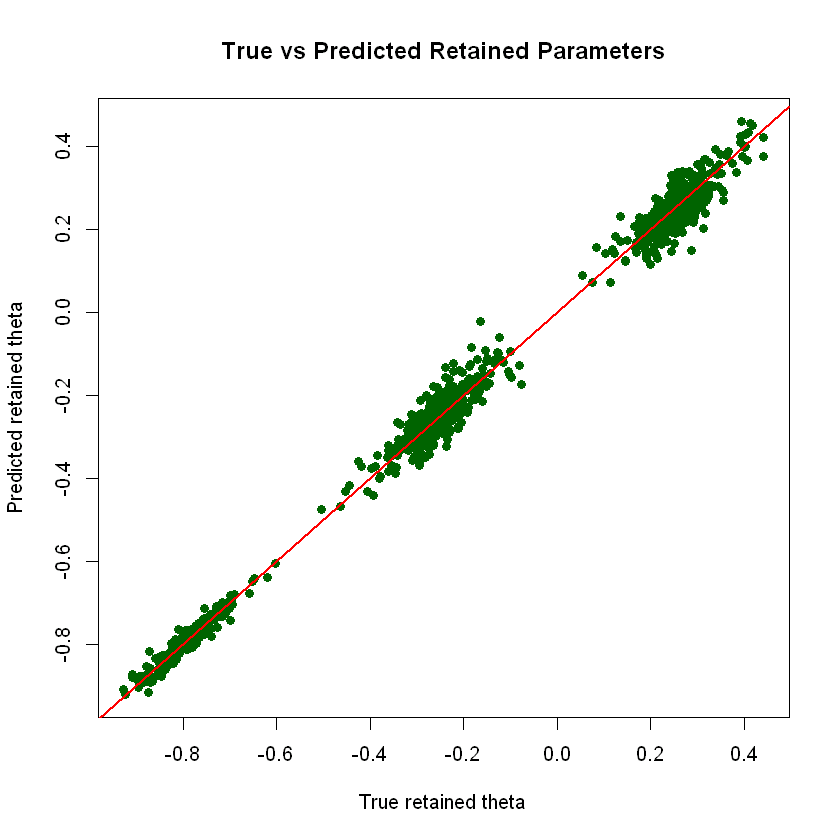

In [3]:
# ============================================================
# EXPERIMENT 3: DIRECT RETAINED PARAMETER PREDICTION
# With R² evaluation for w0, w1, w2
# ============================================================

set.seed(42)

if (!require(nnet)) install.packages("nnet", repos = "https://cloud.r-project.org")
library(nnet)

safe_sd <- function(x) {
  if (length(x) <= 1) return(0)
  s <- sd(x)
  if (is.na(s) || is.nan(s) || is.infinite(s)) return(0)
  s
}

make_poly_design <- function(x, degree_terms = 3) {
  Phi <- sapply(0:(degree_terms - 1), function(k) x^k)
  colnames(Phi) <- paste0("x_power_", 0:(degree_terms - 1))
  as.matrix(Phi)
}

simulate_polynomial_gaussian_yi <- function(
    n = 100,
    degree_terms = 3,
    theta_true = c(2, -3, 1.5),
    x_min = -1,
    x_max = 1,
    min_sd = 0.001,
    seed = NULL
) {
  if (!is.null(seed)) set.seed(seed)

  x <- runif(n, x_min, x_max)
  Phi <- make_poly_design(x, degree_terms)

  y_true <- as.vector(Phi %*% theta_true)
  sigma_i <- sqrt(pmax(abs(y_true), min_sd))

  eps <- rnorm(n, mean = 0, sd = sigma_i)
  y_obs <- y_true + eps

  data.frame(x = x, y = y_obs, y_true = y_true, sigma_i = sigma_i)
}

standardize_xy <- function(x, y) {
  x_sd <- safe_sd(x)
  y_sd <- safe_sd(y)

  if (x_sd == 0) x_sd <- 1
  if (y_sd == 0) y_sd <- 1

  list(
    x = (x - mean(x)) / x_sd,
    y = (y - mean(y)) / y_sd
  )
}

mse_loss <- function(theta, Phi, Y) {
  pred <- as.vector(Phi %*% theta)
  mean((Y - pred)^2)
}

fit_optim_bfgs <- function(Phi, Y, theta_init = NULL, maxit = 1000) {
  if (is.null(theta_init)) {
    theta_init <- rep(0, ncol(Phi))
  }

  fit <- optim(
    par = theta_init,
    fn = mse_loss,
    Phi = Phi,
    Y = Y,
    method = "BFGS",
    control = list(maxit = maxit)
  )

  fit$par
}

r2_score <- function(actual, predicted) {
  ss_res <- sum((actual - predicted)^2)
  ss_tot <- sum((actual - mean(actual))^2)

  if (ss_tot == 0) return(NA)

  1 - (ss_res / ss_tot)
}

interpret_r2 <- function(r2) {
  if (is.na(r2)) return("Undefined")
  if (r2 == 1) return("Perfect prediction")
  if (r2 > 0.95) return("Excellent")
  if (r2 > 0.90) return("Very good")
  if (r2 > 0.80) return("Useful")
  if (r2 <= 0) return("Worse than predicting the mean")
  "Weak / moderate"
}

one_experiment_theta_ret <- function(
    df,
    p_del,
    degree_terms = 3,
    T_GD = 1000
) {
  x <- df$x
  y <- df$y
  n <- nrow(df)

  K_del <- max(1, floor(n * p_del))
  K_del <- min(K_del, n - 1)

  st <- standardize_xy(x, y)
  X <- st$x
  Y <- st$y

  Phi <- make_poly_design(X, degree_terms)

  theta_full <- fit_optim_bfgs(Phi = Phi, Y = Y, maxit = T_GD)

  del_idx <- sample(1:n, K_del, replace = FALSE)
  del_mask <- rep(FALSE, n)
  del_mask[del_idx] <- TRUE

  Phi_ret <- Phi[!del_mask, , drop = FALSE]
  Y_ret <- Y[!del_mask]

  theta_ret <- fit_optim_bfgs(Phi = Phi_ret, Y = Y_ret, maxit = T_GD)

  deleted_points <- as.matrix(df[del_mask, c("x", "y")])
  retained_points <- as.matrix(df[!del_mask, c("x", "y")])

  deleted_points <- deleted_points[order(deleted_points[, 1]), , drop = FALSE]
  retained_points <- retained_points[order(retained_points[, 1]), , drop = FALSE]

  list(
    deleted_points = deleted_points,
    retained_points = retained_points,
    theta_full = theta_full,
    theta_ret = theta_ret,
    K_del = K_del,
    p_del = p_del
  )
}

build_experiment_dataset <- function(
    df,
    n_experiments = 2000,
    degree_terms = 3,
    p_min = 0.01,
    p_max = 0.50,
    T_GD = 1000
) {
  samples <- vector("list", n_experiments)

  for (i in 1:n_experiments) {
    p_now <- runif(1, p_min, p_max)

    samples[[i]] <- one_experiment_theta_ret(
      df = df,
      p_del = p_now,
      degree_terms = degree_terms,
      T_GD = T_GD
    )

    if (i %% 200 == 0) {
      cat("Generated", i, "experiments\n")
    }
  }

  samples
}

embed_and_pool <- function(points_mat, W, b) {
  if (nrow(points_mat) == 0) stop("Empty point set")

  embedded <- sweep(points_mat %*% W, 2, b, "+")

  c(
    colMeans(embedded),
    apply(embedded, 2, max),
    apply(embedded, 2, min),
    apply(embedded, 2, safe_sd)
  )
}

build_meta_table <- function(
    samples,
    embed_dim = 32,
    total_raw_n = 100,
    theta_dim = 3,
    seed = 42
) {
  set.seed(seed)

  W <- matrix(
    rnorm(2 * embed_dim, mean = 0, sd = 0.3),
    nrow = 2,
    ncol = embed_dim
  )

  b <- rnorm(embed_dim, mean = 0, sd = 0.05)

  rows <- vector("list", length(samples))

  for (i in seq_along(samples)) {
    s <- samples[[i]]

    del_vec <- embed_and_pool(s$deleted_points, W, b)
    ret_vec <- embed_and_pool(s$retained_points, W, b)

    row_i <- as.data.frame(as.list(c(del_vec, ret_vec)))

    names(row_i) <- c(
      paste0("del_mean_emb_", 1:embed_dim),
      paste0("del_max_emb_", 1:embed_dim),
      paste0("del_min_emb_", 1:embed_dim),
      paste0("del_sd_emb_", 1:embed_dim),
      paste0("ret_mean_emb_", 1:embed_dim),
      paste0("ret_max_emb_", 1:embed_dim),
      paste0("ret_min_emb_", 1:embed_dim),
      paste0("ret_sd_emb_", 1:embed_dim)
    )

    row_i$p_del <- s$p_del
    row_i$K_del <- s$K_del
    row_i$del_fraction <- s$K_del / total_raw_n

    row_i$deleted_x_mean <- mean(s$deleted_points[,1])
    row_i$deleted_y_mean <- mean(s$deleted_points[,2])
    row_i$retained_x_mean <- mean(s$retained_points[,1])
    row_i$retained_y_mean <- mean(s$retained_points[,2])

    for (j in 1:theta_dim) {
      row_i[[paste0("theta_full_", j)]] <- s$theta_full[j]
      row_i[[paste0("target_theta_ret_", j)]] <- s$theta_ret[j]
    }

    rows[[i]] <- row_i
  }

  na.omit(do.call(rbind, rows))
}

scale_features_train <- function(df_features) {
  means <- sapply(df_features, mean)
  sds <- sapply(df_features, safe_sd)
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  list(data = scaled, means = means, sds = sds)
}

scale_features_apply <- function(df_features, means, sds) {
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  scaled
}

scale_targets_train <- function(Y) {
  means <- apply(Y, 2, mean)
  sds <- apply(Y, 2, safe_sd)
  sds[sds == 0] <- 1

  Y_scaled <- scale(Y, center = means, scale = sds)

  list(
    data = as.matrix(Y_scaled),
    means = means,
    sds = sds
  )
}

scale_targets_apply_inverse <- function(Y_scaled, means, sds) {
  sweep(
    sweep(Y_scaled, 2, sds, "*"),
    2,
    means,
    "+"
  )
}

fit_best_nnet_multi <- function(
    x_train_sc,
    y_train_sc,
    hidden_units = 16,
    decay = 0.001,
    maxit = 1500,
    maxnwts = 60000,
    n_repeats = 5,
    seed = 42
) {
  best_fit <- NULL
  best_sse <- Inf

  for (r in 1:n_repeats) {
    set.seed(seed + r)

    fit_try <- try(
      nnet(
        x = x_train_sc,
        y = y_train_sc,
        size = hidden_units,
        linout = TRUE,
        decay = decay,
        maxit = maxit,
        trace = FALSE,
        MaxNWts = maxnwts
      ),
      silent = TRUE
    )

    if (inherits(fit_try, "try-error")) next

    pred_train <- as.matrix(predict(fit_try, x_train_sc))
    sse <- sum((pred_train - y_train_sc)^2)

    if (is.finite(sse) && sse < best_sse) {
      best_sse <- sse
      best_fit <- fit_try
    }
  }

  if (is.null(best_fit)) {
    stop("All MLP fits failed.")
  }

  best_fit
}

train_and_test_theta_ret_model <- function(
    meta_train,
    meta_test,
    theta_dim = 3,
    hidden_units = 8,
    seed = 42
) {
  theta_ret_cols <- paste0("target_theta_ret_", 1:theta_dim)

  feature_names <- setdiff(names(meta_train), theta_ret_cols)

  x_train <- meta_train[, feature_names, drop = FALSE]
  x_test <- meta_test[, feature_names, drop = FALSE]

  y_train_theta <- as.matrix(meta_train[, theta_ret_cols, drop = FALSE])
  y_test_theta <- as.matrix(meta_test[, theta_ret_cols, drop = FALSE])

  sc_x <- scale_features_train(x_train)

  x_train_sc <- as.matrix(sc_x$data)
  x_test_sc <- as.matrix(
    scale_features_apply(x_test, sc_x$means, sc_x$sds)
  )

  sc_y <- scale_targets_train(y_train_theta)
  y_train_sc <- sc_y$data

  mlp_fit <- fit_best_nnet_multi(
    x_train_sc = x_train_sc,
    y_train_sc = y_train_sc,
    hidden_units = hidden_units,
    seed = seed
  )

  pred_theta_sc <- as.matrix(predict(mlp_fit, x_test_sc))

  pred_theta_ret <- scale_targets_apply_inverse(
    pred_theta_sc,
    sc_y$means,
    sc_y$sds
  )

  theta_rmse <- sqrt(mean((pred_theta_ret - y_test_theta)^2))
  theta_mae <- mean(abs(pred_theta_ret - y_test_theta))

  per_param_rmse_theta <- sqrt(colMeans((pred_theta_ret - y_test_theta)^2))
  per_param_mae_theta <- colMeans(abs(pred_theta_ret - y_test_theta))

  per_param_r2_theta <- c(
    w0 = r2_score(y_test_theta[,1], pred_theta_ret[,1]),
    w1 = r2_score(y_test_theta[,2], pred_theta_ret[,2]),
    w2 = r2_score(y_test_theta[,3], pred_theta_ret[,3])
  )

  list(
    pred_theta_ret = pred_theta_ret,
    true_theta_ret = y_test_theta,
    theta_rmse = theta_rmse,
    theta_mae = theta_mae,
    per_param_rmse_theta = per_param_rmse_theta,
    per_param_mae_theta = per_param_mae_theta,
    per_param_r2_theta = per_param_r2_theta
  )
}

# ============================================================
# MAIN
# ============================================================

degree_terms <- 3
theta_dim <- degree_terms

base_df <- simulate_polynomial_gaussian_yi(
  n = 100,
  degree_terms = degree_terms,
  theta_true = c(2, -3, 1.5),
  x_min = -1,
  x_max = 1,
  seed = 7
)

cat("EXPERIMENT 3: DIRECT RETAINED PARAMETER PREDICTION\n")
cat("Model: y = w0 + w1*x + w2*x^2 + e\n")
cat("Noise: e ~ N(0, |yi|)\n")
cat("Task: m(Ri, Di) -> theta_retained\n")
cat("Total raw points:", nrow(base_df), "\n\n")

samples <- build_experiment_dataset(
  df = base_df,
  n_experiments = 2000,
  degree_terms = degree_terms,
  p_min = 0.01,
  p_max = 0.50,
  T_GD = 1000
)

cat("Total experiments built:", length(samples), "\n\n")

meta_all <- build_meta_table(
  samples = samples,
  embed_dim = 32,
  total_raw_n = nrow(base_df),
  theta_dim = theta_dim,
  seed = 42
)

cat("Total meta rows built:", nrow(meta_all), "\n\n")

theta_ret_cols <- paste0("target_theta_ret_", 1:theta_dim)

cat("Summary of retained theta targets:\n")
print(summary(meta_all[, theta_ret_cols]))

set.seed(42)

idx_meta_train <- sample(
  seq_len(nrow(meta_all)),
  size = floor(0.8 * nrow(meta_all))
)

meta_train <- meta_all[idx_meta_train, ]
meta_test <- meta_all[-idx_meta_train, ]

cat("\nMeta-train rows:", nrow(meta_train), "\n")
cat("Meta-test rows :", nrow(meta_test), "\n\n")

res <- train_and_test_theta_ret_model(
  meta_train = meta_train,
  meta_test = meta_test,
  theta_dim = theta_dim,
  hidden_units = 16,
  seed = 42
)

cat("Theta retained RMSE:", res$theta_rmse, "\n")
cat("Theta retained MAE :", res$theta_mae, "\n\n")

cat("Per-parameter retained theta RMSE:\n")
print(res$per_param_rmse_theta)

cat("\nPer-parameter retained theta MAE:\n")
print(res$per_param_mae_theta)

cat("\nPer-parameter retained theta R²:\n")
print(round(res$per_param_r2_theta, 4))

cat("\nR² Interpretation:\n")
for (name in names(res$per_param_r2_theta)) {
  cat(name, ":", round(res$per_param_r2_theta[name], 4),
      "-", interpret_r2(res$per_param_r2_theta[name]), "\n")
}

# Actual vs predicted table
comparison_table <- data.frame(
  K_del = meta_test$K_del,
  Deletion_Percent = round(100 * meta_test$p_del, 2),

  Actual_w0 = round(res$true_theta_ret[,1], 4),
  Predicted_w0 = round(res$pred_theta_ret[,1], 4),
  Error_w0 = round(res$pred_theta_ret[,1] - res$true_theta_ret[,1], 4),

  Actual_w1 = round(res$true_theta_ret[,2], 4),
  Predicted_w1 = round(res$pred_theta_ret[,2], 4),
  Error_w1 = round(res$pred_theta_ret[,2] - res$true_theta_ret[,2], 4),

  Actual_w2 = round(res$true_theta_ret[,3], 4),
  Predicted_w2 = round(res$pred_theta_ret[,3], 4),
  Error_w2 = round(res$pred_theta_ret[,3] - res$true_theta_ret[,3], 4)
)

cat("\nFirst 20 Actual vs Predicted Test Examples:\n")
print(head(comparison_table, 20))

write.csv(
  comparison_table,
  "actual_vs_predicted_thetaR_with_R2.csv",
  row.names = FALSE
)

cat("\nSaved file: actual_vs_predicted_thetaR_with_R2.csv\n")

plot(
  as.vector(res$true_theta_ret),
  as.vector(res$pred_theta_ret),
  pch = 16,
  col = "darkgreen",
  xlab = "True retained theta",
  ylab = "Predicted retained theta",
  main = "True vs Predicted Retained Parameters"
)

abline(0, 1, col = "red", lwd = 2)

Loading required package: nnet



DIRECT RETAINED PARAMETER PREDICTION WITH FULL DATA FEATURES
Model: y = w0 + w1*x + w2*x^2 + e
Noise: e ~ N(0, |yi|)
Task: m(Full, Ri, Di) -> theta_retained
Total raw points: 100 

Generated 200 experiments
Generated 400 experiments
Generated 600 experiments
Generated 800 experiments
Generated 1000 experiments
Generated 1200 experiments
Generated 1400 experiments
Generated 1600 experiments
Generated 1800 experiments
Generated 2000 experiments
Total experiments built: 2000 

Total meta rows built: 2000 

Summary of retained theta targets:
 target_theta_ret_1 target_theta_ret_2 target_theta_ret_3
 Min.   :-0.50463   Min.   :-0.9592    Min.   :0.05364   
 1st Qu.:-0.28526   1st Qu.:-0.8059    1st Qu.:0.22734   
 Median :-0.25208   Median :-0.7833    Median :0.25460   
 Mean   :-0.25223   Mean   :-0.7832    Mean   :0.25559   
 3rd Qu.:-0.22105   3rd Qu.:-0.7592    3rd Qu.:0.28123   
 Max.   :-0.02946   Max.   :-0.6026    Max.   :0.46222   

Meta-train rows: 1600 
Meta-test rows : 400 

The

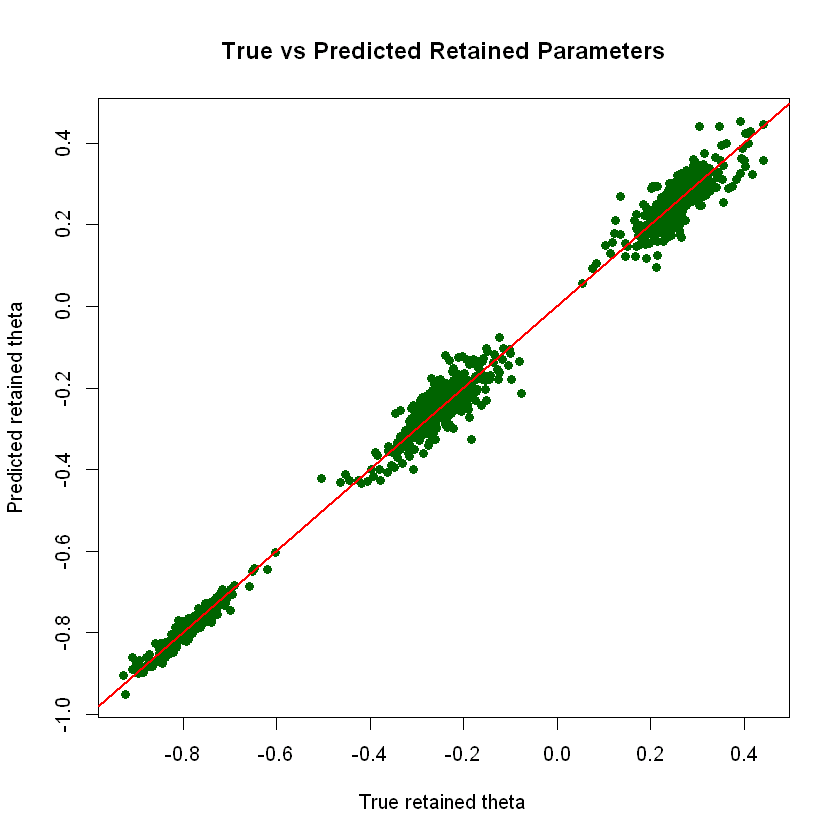

In [1]:
# ============================================================
# DIRECT RETAINED PARAMETER PREDICTION
# Added:
# 1. pooled full-data features
# 2. pooled deleted-data features
# 3. pooled retained-data features
# 4. theta_full as input
# 5. R² for w0, w1, w2
# ============================================================

set.seed(42)

if (!require(nnet)) install.packages("nnet", repos = "https://cloud.r-project.org")
library(nnet)

safe_sd <- function(x) {
  if (length(x) <= 1) return(0)
  s <- sd(x)
  if (is.na(s) || is.nan(s) || is.infinite(s)) return(0)
  s
}

make_poly_design <- function(x, degree_terms = 3) {
  Phi <- sapply(0:(degree_terms - 1), function(k) x^k)
  colnames(Phi) <- paste0("x_power_", 0:(degree_terms - 1))
  as.matrix(Phi)
}

simulate_polynomial_gaussian_yi <- function(
    n = 100,
    degree_terms = 3,
    theta_true = c(2, -3, 1.5),
    x_min = -1,
    x_max = 1,
    min_sd = 0.001,
    seed = NULL
) {
  if (!is.null(seed)) set.seed(seed)

  x <- runif(n, x_min, x_max)
  Phi <- make_poly_design(x, degree_terms)

  y_true <- as.vector(Phi %*% theta_true)
  sigma_i <- sqrt(pmax(abs(y_true), min_sd))

  eps <- rnorm(n, mean = 0, sd = sigma_i)
  y_obs <- y_true + eps

  data.frame(
    x = x,
    y = y_obs,
    y_true = y_true,
    sigma_i = sigma_i
  )
}

standardize_xy <- function(x, y) {
  x_sd <- safe_sd(x)
  y_sd <- safe_sd(y)

  if (x_sd == 0) x_sd <- 1
  if (y_sd == 0) y_sd <- 1

  list(
    x = (x - mean(x)) / x_sd,
    y = (y - mean(y)) / y_sd
  )
}

mse_loss <- function(theta, Phi, Y) {
  pred <- as.vector(Phi %*% theta)
  mean((Y - pred)^2)
}

fit_optim_bfgs <- function(Phi, Y, theta_init = NULL, maxit = 1000) {
  if (is.null(theta_init)) {
    theta_init <- rep(0, ncol(Phi))
  }

  fit <- optim(
    par = theta_init,
    fn = mse_loss,
    Phi = Phi,
    Y = Y,
    method = "BFGS",
    control = list(maxit = maxit)
  )

  fit$par
}

r2_score <- function(actual, predicted) {
  ss_res <- sum((actual - predicted)^2)
  ss_tot <- sum((actual - mean(actual))^2)

  if (ss_tot == 0) return(NA)

  1 - (ss_res / ss_tot)
}

interpret_r2 <- function(r2) {
  if (is.na(r2)) return("Undefined")
  if (r2 == 1) return("Perfect prediction")
  if (r2 > 0.95) return("Excellent")
  if (r2 > 0.90) return("Very good")
  if (r2 > 0.80) return("Useful")
  if (r2 <= 0) return("Worse than predicting the mean")
  "Weak / moderate"
}

one_experiment_theta_ret <- function(
    df,
    p_del,
    degree_terms = 3,
    T_GD = 1000
) {
  x <- df$x
  y <- df$y
  n <- nrow(df)

  K_del <- max(1, floor(n * p_del))
  K_del <- min(K_del, n - 1)

  st <- standardize_xy(x, y)
  X <- st$x
  Y <- st$y

  Phi <- make_poly_design(X, degree_terms)

  theta_full <- fit_optim_bfgs(
    Phi = Phi,
    Y = Y,
    maxit = T_GD
  )

  del_idx <- sample(1:n, K_del, replace = FALSE)

  del_mask <- rep(FALSE, n)
  del_mask[del_idx] <- TRUE

  Phi_ret <- Phi[!del_mask, , drop = FALSE]
  Y_ret <- Y[!del_mask]

  theta_ret <- fit_optim_bfgs(
    Phi = Phi_ret,
    Y = Y_ret,
    maxit = T_GD
  )

  full_points <- as.matrix(df[, c("x", "y")])
  deleted_points <- as.matrix(df[del_mask, c("x", "y")])
  retained_points <- as.matrix(df[!del_mask, c("x", "y")])

  full_points <- full_points[order(full_points[, 1]), , drop = FALSE]
  deleted_points <- deleted_points[order(deleted_points[, 1]), , drop = FALSE]
  retained_points <- retained_points[order(retained_points[, 1]), , drop = FALSE]

  list(
    full_points = full_points,
    deleted_points = deleted_points,
    retained_points = retained_points,
    theta_full = theta_full,
    theta_ret = theta_ret,
    K_del = K_del,
    p_del = p_del
  )
}

build_experiment_dataset <- function(
    df,
    n_experiments = 2000,
    degree_terms = 3,
    p_min = 0.01,
    p_max = 0.50,
    T_GD = 1000
) {
  samples <- vector("list", n_experiments)

  for (i in 1:n_experiments) {
    p_now <- runif(1, p_min, p_max)

    samples[[i]] <- one_experiment_theta_ret(
      df = df,
      p_del = p_now,
      degree_terms = degree_terms,
      T_GD = T_GD
    )

    if (i %% 200 == 0) {
      cat("Generated", i, "experiments\n")
    }
  }

  samples
}

embed_and_pool <- function(points_mat, W, b) {
  if (nrow(points_mat) == 0) stop("Empty point set")

  embedded <- sweep(points_mat %*% W, 2, b, "+")

  c(
    colMeans(embedded),
    apply(embedded, 2, max),
    apply(embedded, 2, min),
    apply(embedded, 2, safe_sd)
  )
}

make_pool_names <- function(prefix, embed_dim) {
  c(
    paste0(prefix, "_mean_emb_", 1:embed_dim),
    paste0(prefix, "_max_emb_", 1:embed_dim),
    paste0(prefix, "_min_emb_", 1:embed_dim),
    paste0(prefix, "_sd_emb_", 1:embed_dim)
  )
}

build_meta_table <- function(
    samples,
    embed_dim = 32,
    total_raw_n = 100,
    theta_dim = 3,
    seed = 42
) {
  set.seed(seed)

  W <- matrix(
    rnorm(2 * embed_dim, mean = 0, sd = 0.3),
    nrow = 2,
    ncol = embed_dim
  )

  b <- rnorm(embed_dim, mean = 0, sd = 0.05)

  rows <- vector("list", length(samples))

  for (i in seq_along(samples)) {
    s <- samples[[i]]

    full_vec <- embed_and_pool(s$full_points, W, b)
    del_vec <- embed_and_pool(s$deleted_points, W, b)
    ret_vec <- embed_and_pool(s$retained_points, W, b)

    row_i <- as.data.frame(as.list(c(full_vec, del_vec, ret_vec)))

    names(row_i) <- c(
      make_pool_names("full", embed_dim),
      make_pool_names("del", embed_dim),
      make_pool_names("ret", embed_dim)
    )

    # Deletion information
    row_i$p_del <- s$p_del
    row_i$K_del <- s$K_del
    row_i$del_fraction <- s$K_del / total_raw_n

    # Simple raw-data summaries
    row_i$full_x_mean <- mean(s$full_points[,1])
    row_i$full_y_mean <- mean(s$full_points[,2])
    row_i$full_x_sd <- safe_sd(s$full_points[,1])
    row_i$full_y_sd <- safe_sd(s$full_points[,2])

    row_i$deleted_x_mean <- mean(s$deleted_points[,1])
    row_i$deleted_y_mean <- mean(s$deleted_points[,2])
    row_i$deleted_x_sd <- safe_sd(s$deleted_points[,1])
    row_i$deleted_y_sd <- safe_sd(s$deleted_points[,2])

    row_i$retained_x_mean <- mean(s$retained_points[,1])
    row_i$retained_y_mean <- mean(s$retained_points[,2])
    row_i$retained_x_sd <- safe_sd(s$retained_points[,1])
    row_i$retained_y_sd <- safe_sd(s$retained_points[,2])

    # Add theta_full as useful input
    for (j in 1:theta_dim) {
      row_i[[paste0("theta_full_", j)]] <- s$theta_full[j]
    }

    # Target: retained parameters
    for (j in 1:theta_dim) {
      row_i[[paste0("target_theta_ret_", j)]] <- s$theta_ret[j]
    }

    rows[[i]] <- row_i
  }

  na.omit(do.call(rbind, rows))
}

scale_features_train <- function(df_features) {
  means <- sapply(df_features, mean)
  sds <- sapply(df_features, safe_sd)
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  list(data = scaled, means = means, sds = sds)
}

scale_features_apply <- function(df_features, means, sds) {
  sds[sds == 0] <- 1

  scaled <- as.data.frame(scale(df_features, center = means, scale = sds))
  scaled[is.na(scaled)] <- 0

  scaled
}

scale_targets_train <- function(Y) {
  means <- apply(Y, 2, mean)
  sds <- apply(Y, 2, safe_sd)
  sds[sds == 0] <- 1

  Y_scaled <- scale(Y, center = means, scale = sds)

  list(
    data = as.matrix(Y_scaled),
    means = means,
    sds = sds
  )
}

scale_targets_apply_inverse <- function(Y_scaled, means, sds) {
  sweep(
    sweep(Y_scaled, 2, sds, "*"),
    2,
    means,
    "+"
  )
}

fit_best_nnet_multi <- function(
    x_train_sc,
    y_train_sc,
    hidden_units = 16,
    decay = 0.001,
    maxit = 1500,
    maxnwts = 100000,
    n_repeats = 5,
    seed = 42
) {
  best_fit <- NULL
  best_sse <- Inf

  for (r in 1:n_repeats) {
    set.seed(seed + r)

    fit_try <- try(
      nnet(
        x = x_train_sc,
        y = y_train_sc,
        size = hidden_units,
        linout = TRUE,
        decay = decay,
        maxit = maxit,
        trace = FALSE,
        MaxNWts = maxnwts
      ),
      silent = TRUE
    )

    if (inherits(fit_try, "try-error")) next

    pred_train <- as.matrix(predict(fit_try, x_train_sc))
    sse <- sum((pred_train - y_train_sc)^2)

    if (is.finite(sse) && sse < best_sse) {
      best_sse <- sse
      best_fit <- fit_try
    }
  }

  if (is.null(best_fit)) {
    stop("All MLP fits failed.")
  }

  best_fit
}

train_and_test_theta_ret_model <- function(
    meta_train,
    meta_test,
    theta_dim = 3,
    hidden_units = 16,
    seed = 42
) {
  theta_ret_cols <- paste0("target_theta_ret_", 1:theta_dim)

  feature_names <- setdiff(names(meta_train), theta_ret_cols)

  x_train <- meta_train[, feature_names, drop = FALSE]
  x_test <- meta_test[, feature_names, drop = FALSE]

  y_train_theta <- as.matrix(meta_train[, theta_ret_cols, drop = FALSE])
  y_test_theta <- as.matrix(meta_test[, theta_ret_cols, drop = FALSE])

  sc_x <- scale_features_train(x_train)

  x_train_sc <- as.matrix(sc_x$data)

  x_test_sc <- as.matrix(
    scale_features_apply(x_test, sc_x$means, sc_x$sds)
  )

  sc_y <- scale_targets_train(y_train_theta)
  y_train_sc <- sc_y$data

  mlp_fit <- fit_best_nnet_multi(
    x_train_sc = x_train_sc,
    y_train_sc = y_train_sc,
    hidden_units = hidden_units,
    seed = seed
  )

  pred_theta_sc <- as.matrix(predict(mlp_fit, x_test_sc))

  pred_theta_ret <- scale_targets_apply_inverse(
    pred_theta_sc,
    sc_y$means,
    sc_y$sds
  )

  theta_rmse <- sqrt(mean((pred_theta_ret - y_test_theta)^2))
  theta_mae <- mean(abs(pred_theta_ret - y_test_theta))

  per_param_rmse_theta <- sqrt(colMeans((pred_theta_ret - y_test_theta)^2))
  per_param_mae_theta <- colMeans(abs(pred_theta_ret - y_test_theta))

  per_param_r2_theta <- c(
    w0 = r2_score(y_test_theta[,1], pred_theta_ret[,1]),
    w1 = r2_score(y_test_theta[,2], pred_theta_ret[,2]),
    w2 = r2_score(y_test_theta[,3], pred_theta_ret[,3])
  )

  list(
    pred_theta_ret = pred_theta_ret,
    true_theta_ret = y_test_theta,
    theta_rmse = theta_rmse,
    theta_mae = theta_mae,
    per_param_rmse_theta = per_param_rmse_theta,
    per_param_mae_theta = per_param_mae_theta,
    per_param_r2_theta = per_param_r2_theta
  )
}

# ============================================================
# MAIN
# ============================================================

degree_terms <- 3
theta_dim <- degree_terms

base_df <- simulate_polynomial_gaussian_yi(
  n = 100,
  degree_terms = degree_terms,
  theta_true = c(2, -3, 1.5),
  x_min = -1,
  x_max = 1,
  seed = 7
)

cat("DIRECT RETAINED PARAMETER PREDICTION WITH FULL DATA FEATURES\n")
cat("Model: y = w0 + w1*x + w2*x^2 + e\n")
cat("Noise: e ~ N(0, |yi|)\n")
cat("Task: m(Full, Ri, Di) -> theta_retained\n")
cat("Total raw points:", nrow(base_df), "\n\n")

samples <- build_experiment_dataset(
  df = base_df,
  n_experiments = 2000,
  degree_terms = degree_terms,
  p_min = 0.01,
  p_max = 0.50,
  T_GD = 1000
)

cat("Total experiments built:", length(samples), "\n\n")

meta_all <- build_meta_table(
  samples = samples,
  embed_dim = 32,
  total_raw_n = nrow(base_df),
  theta_dim = theta_dim,
  seed = 42
)

cat("Total meta rows built:", nrow(meta_all), "\n\n")

theta_ret_cols <- paste0("target_theta_ret_", 1:theta_dim)

cat("Summary of retained theta targets:\n")
print(summary(meta_all[, theta_ret_cols]))

set.seed(42)

idx_meta_train <- sample(
  seq_len(nrow(meta_all)),
  size = floor(0.8 * nrow(meta_all))
)

meta_train <- meta_all[idx_meta_train, ]
meta_test <- meta_all[-idx_meta_train, ]

cat("\nMeta-train rows:", nrow(meta_train), "\n")
cat("Meta-test rows :", nrow(meta_test), "\n\n")

res <- train_and_test_theta_ret_model(
  meta_train = meta_train,
  meta_test = meta_test,
  theta_dim = theta_dim,
  hidden_units = 16,
  seed = 42
)

cat("Theta retained RMSE:", res$theta_rmse, "\n")
cat("Theta retained MAE :", res$theta_mae, "\n\n")

cat("Per-parameter retained theta RMSE:\n")
print(res$per_param_rmse_theta)

cat("\nPer-parameter retained theta MAE:\n")
print(res$per_param_mae_theta)

cat("\nPer-parameter retained theta R²:\n")
print(round(res$per_param_r2_theta, 4))

cat("\nR² Interpretation:\n")
for (name in names(res$per_param_r2_theta)) {
  cat(
    name, ":",
    round(res$per_param_r2_theta[name], 4),
    "-",
    interpret_r2(res$per_param_r2_theta[name]),
    "\n"
  )
}

comparison_table <- data.frame(
  K_del = meta_test$K_del,
  Deletion_Percent = round(100 * meta_test$K_del / nrow(base_df), 2),

  Actual_w0 = round(res$true_theta_ret[,1], 4),
  Predicted_w0 = round(res$pred_theta_ret[,1], 4),
  Error_w0 = round(res$pred_theta_ret[,1] - res$true_theta_ret[,1], 4),

  Actual_w1 = round(res$true_theta_ret[,2], 4),
  Predicted_w1 = round(res$pred_theta_ret[,2], 4),
  Error_w1 = round(res$pred_theta_ret[,2] - res$true_theta_ret[,2], 4),

  Actual_w2 = round(res$true_theta_ret[,3], 4),
  Predicted_w2 = round(res$pred_theta_ret[,3], 4),
  Error_w2 = round(res$pred_theta_ret[,3] - res$true_theta_ret[,3], 4)
)

cat("\nFirst 20 Actual vs Predicted Test Examples:\n")
print(head(comparison_table, 20))

write.csv(
  comparison_table,
  "actual_vs_predicted_thetaR_full_features_R2.csv",
  row.names = FALSE
)

cat("\nSaved file: actual_vs_predicted_thetaR_full_features_R2.csv\n")

plot(
  as.vector(res$true_theta_ret),
  as.vector(res$pred_theta_ret),
  pch = 16,
  col = "darkgreen",
  xlab = "True retained theta",
  ylab = "Predicted retained theta",
  main = "True vs Predicted Retained Parameters"
)

abline(0, 1, col = "red", lwd = 2)